# Ecuación de onda | Ecuaciones diferenciales parciales

En esta unidad se aplica la mecánica clásica a la descripción de medios continuos. Se enfatizan problemas poco tratados en textos tradicionales, se estudian: 

- Ondas en cuerdas realistas (fricción, tensión y densidad variables)
- Efectos no lineales
- Métodos numéricos: algoritmo leapfrog

Extensión de los modelos de onda:

Dinámica de fluidos: 

Ondas en una cuerda, consideremos una cuerda de longitud $L$ con densidad $\rho(x)$ y tensión $T(x)$.
Si T = cte y $\rho$ = cte, la ecuación de onda es:
$$\frac{\partial^2 u}{\partial t^2} = c^2 \frac{\partial^2 u}{\partial x^2}$$
donde $c = \sqrt{\frac{T}{\rho}}$ es la velocidad de propagación de la onda.

Condiciones necesarias, para una solución única se requieren:
- Condiciones iniciales: $u(x,0) = f(x)$
- Condiciones de frontera: por ejemplo, $u(0,t) = 0$ y $u(L,t) = 0$ para una cuerda fija en ambos extremos.
- Condición inicial de velocidad: $\frac{\partial u}{\partial t}(x,0) = g(x)$

Discretización numérica: 
Definimos una red espacio-temporal: 
- $u(x,t) = u(i\Delta x, j\Delta t) = u_{i,j}$
- Aproximaciones de diferencias finitas:
$$\frac{\partial^2 u}{\partial t^2} \approx \frac{u_{i,j+1} - 2u_{i,j} + u_{i,j-1}}{\Delta t^2}$$
$$\frac{\partial^2 u}{\partial x^2} \approx \frac{u_{i+1,j} - 2u_{i,j} + u_{i-1,j}}{\Delta x^2}$$

Forma discreta de la ecuación de onda:
$$\frac{u_{i,j+1} - 2u_{i,j} + u_{i,j-1}}{\Delta t^2} = c^2 \frac{u_{i+1,j} - 2u_{i,j} + u_{i-1,j}}{\Delta x^2}$$
Reorganizando:
$$u_{i,j+1} = 2u_{i,j} - u_{i,j-1} + \left(\frac{c \Delta t}{\Delta x}\right)^2 (u_{i+1,j} - 2u_{i,j} + u_{i-1,j})$$

Algoritmo leapfrog:
1. Inicializar $u_{i,0} = f(i\Delta x)$ y $u_{i,1} = u_{i,0} + \Delta t g(i\Delta x)$
2. Para cada paso de tiempo $j$ desde 1 hasta el número de pasos deseado:
   - Para cada punto espacial $i$ desde 1 hasta $N-1$:
     - Calcular $u_{i,j+1}$ usando la fórmula anterior
   - Aplicar condiciones de frontera: $u_{0,j+1} = 0$ y $u_{N,j+1} = 0$
3. Repetir hasta alcanzar el tiempo final deseado.

Condiciones de estabilidad:
Para garantizar la estabilidad del método numérico, se debe cumplir la condición de Courant-Friedrichs-Lewy (CFL):
$$\frac{c \Delta t}{\Delta x} \leq 1$$
Esto asegura que la onda no se propague más rápido que la velocidad de la onda en el medio, evitando inestabilidades numéricas.

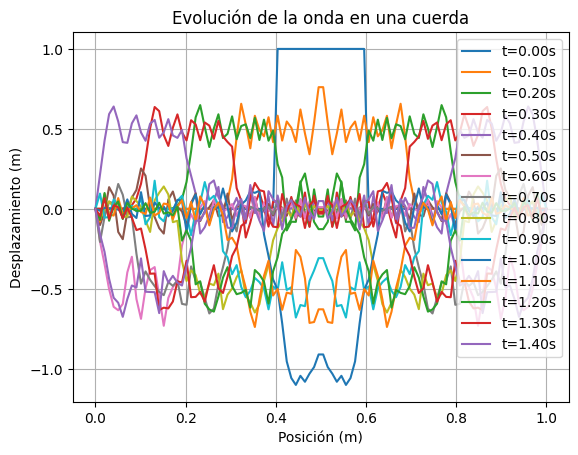

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros físicos
L = 1.0  # Longitud de la cuerda
c = 1.0  # Velocidad de la onda

# Discretización
Nx = 100  # Número de puntos en el espacio
dx = L / (Nx - 1)  # Paso espacial

dt = 0.005  # Paso temporal
Nt = 300  # Número de pasos temporales

# Estabilidad
CFL = c * dt / dx
if CFL > 1:
    raise ValueError("El número de Courant-Friedrichs-Lewy (CFL) debe ser menor o igual a 1 para la estabilidad.")

# Malla espacial
x = np.linspace(0, L, Nx)

# Inicialización de la onda
u = np.zeros((Nt,Nx))  # Desplazamiento en el tiempo actual

# Condición inicial (gaussiana)
# u[1, :] = np.exp(-100 * (x - L/2)**2)

# Condición inicial diferente a gaussiana (opcional)
# u[1, :] = np.sin(np.pi * x / L)  # Otra forma de onda inicial

# Otra condición inicial (CREATIVA) Braithwaite
u[1, :] = np.where((x > 0.4) & (x < 0.6), 1.0, 0.0)  # Pulso rectangular

# Velocidad inicial 0
u[0, :] = u[1, :]

# Evolución temporal usando leapfrog
for j in range(1, Nt-1):
    for i in range(1, Nx-1):
        u[j+1, i] = 2 * u[j, i] - u[j-1, i] + CFL**2 * (u[j, i+1] - 2 * u[j, i] + u[j, i-1])
    # Condiciones de frontera (fijas)
    u[j+1, 0] = 0
    u[j+1, -1] = 0

# Visualización
for k in range(0, Nt, 20):
    plt.plot(x, u[k, :], label=f't={k*dt:.2f}s')

plt.title('Evolución de la onda en una cuerda')
plt.xlabel('Posición (m)')
plt.ylabel('Desplazamiento (m)')
plt.legend()
plt.grid()
plt.show()